In [2]:
# Célula 1: imports e configuração 
from google.cloud import bigquery
import pandas as pd
import os
import matplotlib.pyplot as plt
import numpy as np

# Criar pastas necessárias
os.makedirs("../figuras", exist_ok=True)
os.makedirs("../data/processed", exist_ok=True)

# Sem credentials.json — usa a autenticação do gcloud feita no terminal
PROJECT_ID = "ps-analytica-495522"
client = bigquery.Client(project=PROJECT_ID)

print("Conexão com BigQuery configurada!")

Conexão com BigQuery configurada!


In [3]:
# ver como os dados estão organizados
query_explorar = """
SELECT *
FROM `datario.adm_central_atendimento_1746.chamado`
LIMIT 5
"""

df_amostra = client.query(query_explorar).to_dataframe()

print("Colunas disponíveis:")
print(df_amostra.columns.tolist())
print("\nAmostra dos dados:")
print(df_amostra.head())

Colunas disponíveis:
['id_chamado', 'id_origem_ocorrencia', 'data_inicio', 'data_fim', 'id_bairro', 'id_territorialidade', 'id_logradouro', 'numero_logradouro', 'id_unidade_organizacional', 'nome_unidade_organizacional', 'id_unidade_organizacional_mae', 'unidade_organizacional_ouvidoria', 'categoria', 'id_tipo', 'tipo', 'id_subtipo', 'subtipo', 'status', 'longitude', 'latitude', 'data_alvo_finalizacao', 'data_alvo_diagnostico', 'data_real_diagnostico', 'tempo_prazo', 'prazo_unidade', 'prazo_tipo', 'dentro_prazo', 'situacao', 'tipo_situacao', 'justificativa_status', 'reclamacoes', 'extracted_at', 'updated_at', 'data_particao']

Amostra dos dados:
  id_chamado id_origem_ocorrencia         data_inicio            data_fim  \
0      76373                    1 2010-12-01 22:17:55 2010-12-08 13:28:02   
1      76340                    1 2010-12-01 21:13:32 2010-12-09 16:13:04   
2      75746                    1 2010-12-01 08:26:58 2010-12-02 12:17:15   
3      76064                    1 2010

In [4]:
query_tipos = """
SELECT tipo, subtipo, COUNT(*) as total
FROM `datario.adm_central_atendimento_1746.chamado`
GROUP BY tipo, subtipo
ORDER BY total DESC
LIMIT 50
"""

df_tipos = client.query(query_tipos).to_dataframe()
print(df_tipos.to_string())

                                         tipo                                                                                     subtipo    total
0                            Remoção Gratuita                                                       Remoção de entulho e bens inservíveis  2591357
1                    Estacionamento irregular                                         Fiscalização de estacionamento irregular de veículo  1807946
2                          Iluminação Pública                                                                   Reparo de lâmpada apagada   928990
3                                Pavimentação                                        Reparo de buraco, deformação ou afundamento na pista   547371
4                              Cadastro Único                                 Informações sobre inscrição e atualização do Cadastro Único   445442
5                      Limpeza de logradouros                                                           Remoção de res

In [5]:
# Célula 3: explorar subtipos de drenagem
query_tipos_drenagem = """
SELECT tipo, subtipo, COUNT(*) as total
FROM `datario.adm_central_atendimento_1746.chamado`
WHERE
    LOWER(tipo) LIKE '%drenagem%'
    OR LOWER(subtipo) LIKE '%alagamento%'
    OR LOWER(subtipo) LIKE '%enchente%'
    OR LOWER(subtipo) LIKE '%inundac%'
    OR LOWER(subtipo) LIKE '%pluvial%'
    OR LOWER(subtipo) LIKE '%bueiro%'
GROUP BY tipo, subtipo
ORDER BY total DESC
"""

df_tipos_drenagem = client.query(query_tipos_drenagem).to_dataframe()
print(df_tipos_drenagem.to_string())

                                        tipo                                                                                                                         subtipo   total
0                      Drenagem e Saneamento                                                                     Manutenção/Desobstrução de ramais de águas pluviais e ralos  243979
1                      Drenagem e Saneamento                                                                                                   Reposição de tampão ou grelha  107434
2                      Drenagem e Saneamento                                                              Conservação de bueiros, galerias, ramais de águas pluviais e ralos   52162
3                      Drenagem e Saneamento                                                                                                 Desobstrução de ramais de ralos   30976
4                      Drenagem e Saneamento                                            Informa

In [6]:
query_alagamento = """
SELECT
    id_chamado,
    id_origem_ocorrencia,
    data_inicio,
    data_fim,
    tipo,
    subtipo,
    status,
    situacao,
    id_bairro,
    latitude,
    longitude,
    CASE
        -- Eventos reais de alagamento
        WHEN subtipo IN (
            'Enchentes e saneamento - Rio-Águas',
            'Enchentes e saneamento',
            'Informações sobre alagamentos na cidade',
            'Vistoria em inundação ou alagamento',
            'Inundação / alagamento - Defesa Civil '
        ) THEN 'evento_alagamento'

        -- Obras e reparos — ambíguo, separado para análise
        WHEN subtipo IN (
            'Obras de reparo, canalização ou limpeza de rio, canal ou valão - solicitação',
            'Informações sobre obras de reparo, canalização ou limpeza de rio, canal ou valão',
            'Obras de drenagem - aprovação',
            'Reparos de sistema de drenagem',
            'Projetos - controle de enchentes',
            'Informações de projetos - controle de enchentes'
        ) THEN 'obra_reparo'

        -- Manutenção preventiva de infraestrutura
        WHEN subtipo IN (
            'Manutenção/Desobstrução de ramais de águas pluviais e ralos',
            'Reposição de tampão ou grelha',
            'Conservação de bueiros, galerias, ramais de águas pluviais e ralos',
            'Desobstrução de ramais de ralos',
            'Renivelamento de tampão ou grelha',
            'Reposição de Grelha ou Tampão',
            'Reposição de grelha.',
            'Reposição de tampão.',
            'Limpeza de vala de drenagem',
            'Fiscalização de drenagem irregular',
            'Desobstrução de bueiros (após vistoria da SMS)',
            'Desobstrução de bueiros na TransOeste',
            'Desobstrução de bueiros na Transcarioca',
            'Teste - Desobstrução de bueiros',
            'Limpeza de GAP - caixas de ralos e praças de visita',
            'Reposição de grelhas e tampões GAP',
            'Renivelamento de tampões',
            'Serviços da Rio Águas - Drenagem e Saneamento',
            'Limpeza de vala de drenagem',
            'Danos aos rios e Faixa Non Aedificandi'
        ) THEN 'manutencao'

        -- Informativos e administrativos
        ELSE 'informativo'
    END AS categoria_chamado
FROM `datario.adm_central_atendimento_1746.chamado`
WHERE
    LOWER(tipo) LIKE '%drenagem%'
    OR LOWER(tipo) LIKE '%enchente%'
    OR LOWER(tipo) LIKE '%alagamento%' 
    OR LOWER(tipo) LIKE '%inundac%'     
    OR LOWER(subtipo) LIKE '%alagamento%'
    OR LOWER(subtipo) LIKE '%enchente%'
    OR LOWER(subtipo) LIKE '%inundac%'
    OR LOWER(subtipo) LIKE '%pluvial%'
    OR LOWER(subtipo) LIKE '%bueiro%'
ORDER BY data_inicio
"""

print("Rodando consulta...")
df_alagamento = client.query(query_alagamento).to_dataframe()
print(f"Total de chamados: {len(df_alagamento):,}")
print(f"\nDistribuição por categoria:")
print(df_alagamento["categoria_chamado"].value_counts())

Rodando consulta...
Total de chamados: 555,419

Distribuição por categoria:
categoria_chamado
manutencao           477898
informativo           55177
obra_reparo           19186
evento_alagamento      3158
Name: count, dtype: int64


In [7]:
# Célula 5: pré-processamento
df_alagamento["data_inicio"] = pd.to_datetime(df_alagamento["data_inicio"], errors="coerce")
df_alagamento["data_fim"]    = pd.to_datetime(df_alagamento["data_fim"], errors="coerce")

antes = len(df_alagamento)
df_alagamento = df_alagamento.dropna(subset=["data_inicio"])
print(f"Linhas removidas por data inválida: {antes - len(df_alagamento):,}")

df_alagamento["data"]       = df_alagamento["data_inicio"].dt.date
df_alagamento["ano"]        = df_alagamento["data_inicio"].dt.year
df_alagamento["mes"]        = df_alagamento["data_inicio"].dt.month
df_alagamento["hora"]       = df_alagamento["data_inicio"].dt.hour
df_alagamento["dia_semana"] = df_alagamento["data_inicio"].dt.dayofweek

print(f"\nPeríodo coberto:")
print(f"  Início: {df_alagamento['data_inicio'].min()}")
print(f"  Fim:    {df_alagamento['data_inicio'].max()}")
print(f"\nDistribuição por ano:")
print(df_alagamento.groupby("ano").size().sort_index())

Linhas removidas por data inválida: 0

Período coberto:
  Início: 2010-06-01 00:00:00
  Fim:    2026-05-07 00:08:17

Distribuição por ano:
ano
2010     1753
2011    17068
2012    28736
2013    41957
2014    29097
2015    26306
2016    30683
2017    26636
2018    30496
2019    33264
2020    21474
2021    28346
2022    32915
2023    63146
2024    67847
2025    54275
2026    21420
dtype: int64


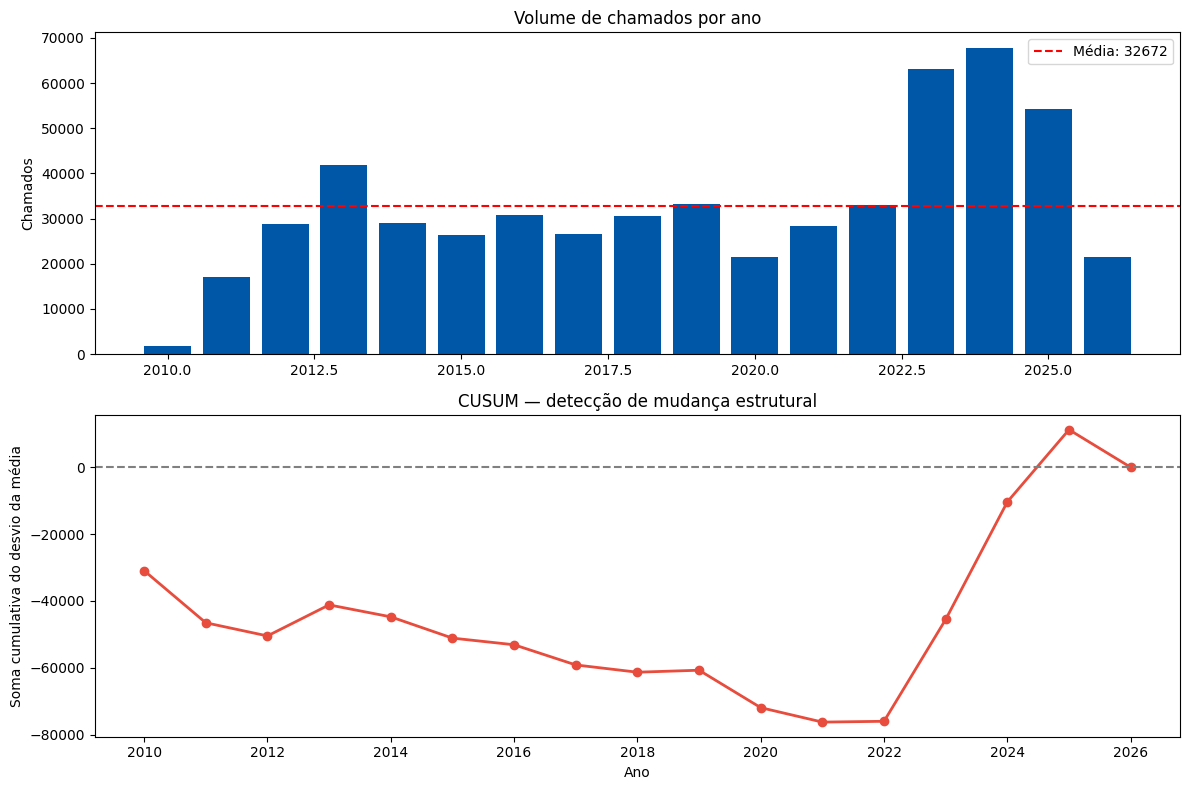

In [8]:
# Célula 6: análise de mudança estrutural com CUSUM 
import matplotlib.pyplot as plt

por_ano = df_alagamento.groupby("ano").size().reset_index(name="chamados")

# CUSUM
media = por_ano["chamados"].mean()
por_ano["cusum"] = (por_ano["chamados"] - media).cumsum()

fig, axes = plt.subplots(2, 1, figsize=(12, 8))

# Gráfico 1: volume por ano
axes[0].bar(por_ano["ano"], por_ano["chamados"], color="#0057A8")
axes[0].axhline(media, color="red", linestyle="--", label=f"Média: {media:.0f}")
axes[0].set_title("Volume de chamados por ano")
axes[0].set_ylabel("Chamados")
axes[0].legend()

# Gráfico 2: CUSUM
axes[1].plot(por_ano["ano"], por_ano["cusum"], marker="o", color="#E74C3C", linewidth=2)
axes[1].axhline(0, color="gray", linestyle="--")
axes[1].set_title("CUSUM — detecção de mudança estrutural")
axes[1].set_ylabel("Soma cumulativa do desvio da média")
axes[1].set_xlabel("Ano")

plt.tight_layout()
plt.savefig("../figuras/cusum_anomalia.png", dpi=150)
plt.show()

## Hipótese 1: A mudança repentina nos chamados é referente a alguma mudança na plataforma de denúncia

In [9]:
# Célula 7: investigação das hipóteses de mudança estrutural 

print("=" * 60)
print("HIPÓTESE 1: Novo canal de atendimento")
print("=" * 60)

# id_origem_ocorrencia indica o canal pelo qual o chamado foi feito
origem_por_ano = (
    df_alagamento.groupby(["ano", "id_origem_ocorrencia"])
    .size()
    .reset_index(name="chamados")
    .sort_values(["ano", "chamados"], ascending=[True, False])
)

# Comparar distribuição de origens antes e depois de 2023
pre  = df_alagamento[df_alagamento["ano"] < 2023]["id_origem_ocorrencia"].value_counts(normalize=True) * 100
pos  = df_alagamento[df_alagamento["ano"] >= 2023]["id_origem_ocorrencia"].value_counts(normalize=True) * 100

comparacao_origem = pd.DataFrame({
    "pre_2023_%": pre,
    "pos_2023_%": pos
}).fillna(0).round(1)

print(comparacao_origem.to_string())

HIPÓTESE 1: Novo canal de atendimento
                      pre_2023_%  pos_2023_%
id_origem_ocorrencia                        
1                           70.8        29.2
10                           0.0         0.0
11                          13.7         9.4
12                           0.9         0.0
13                          13.2        54.3
15                           0.0         0.0
16                           0.1         0.0
17                           0.0         0.1
18                           0.1         0.1
19                           0.3         0.0
2                            0.2         0.0
21                           0.0         0.0
22                           0.0         0.0
23                           0.0         0.0
26                           0.0         0.0
28                           0.0         6.9
3                            0.0         0.0
5                            0.1         0.0
6                            0.6         0.0
8                

Eventos reais por ano:
 ano  eventos    cusum
2011      121  -76.375
2012      151 -122.750
2013      561  240.875
2014      388  431.500
2015      300  534.125
2016      378  714.750
2017      309  826.375
2018      187  816.000
2019      134  752.625
2020       87  642.250
2021       80  524.875
2022       97  424.500
2023      134  361.125
2024      122  285.750
2025       88  176.375
2026       21    0.000


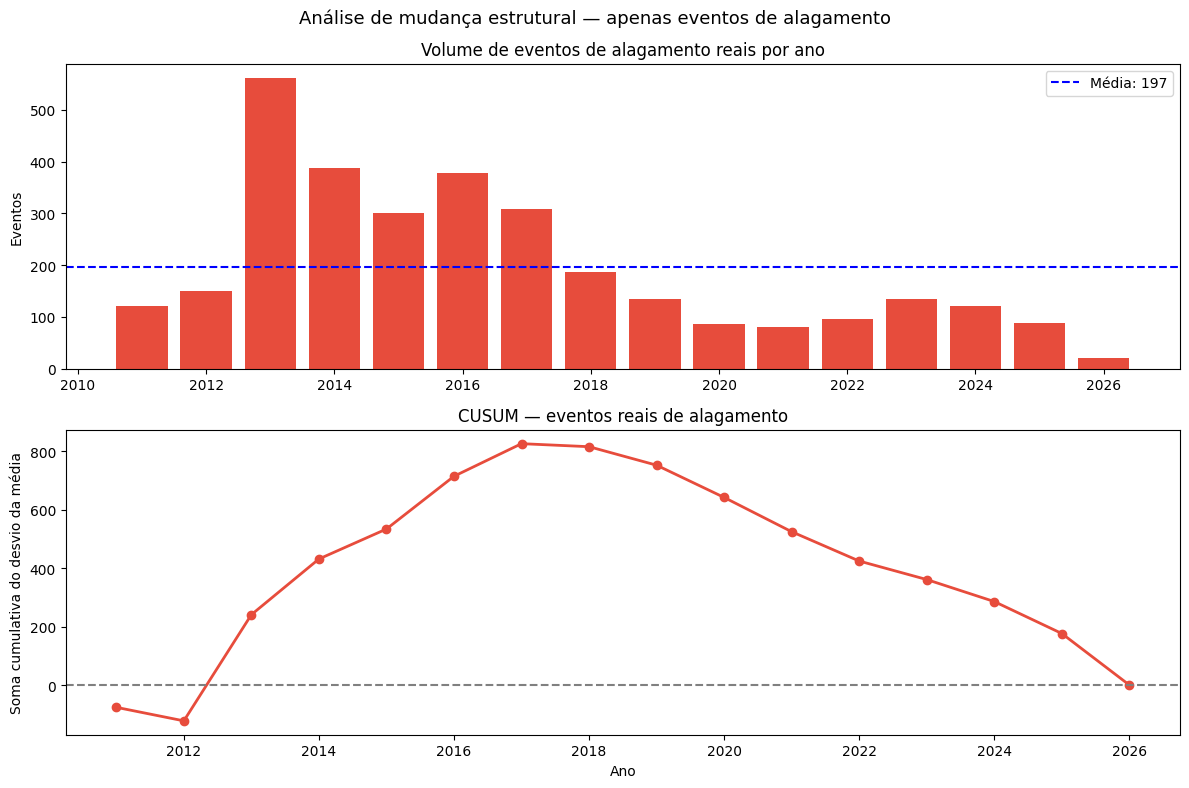

In [10]:
# ── Célula 8 revisada: CUSUM apenas com eventos reais ──
import matplotlib.pyplot as plt

por_ano_eventos = (
    df_alagamento[df_alagamento["categoria_chamado"] == "evento_alagamento"]
    .groupby("ano")
    .size()
    .reset_index(name="eventos")
)

# CUSUM
media = por_ano_eventos["eventos"].mean()
por_ano_eventos["cusum"] = (por_ano_eventos["eventos"] - media).cumsum()

print("Eventos reais por ano:")
print(por_ano_eventos.to_string(index=False))

fig, axes = plt.subplots(2, 1, figsize=(12, 8))

# Volume de eventos reais por ano
axes[0].bar(por_ano_eventos["ano"], por_ano_eventos["eventos"], color="#E74C3C")
axes[0].axhline(media, color="blue", linestyle="--", label=f"Média: {media:.0f}")
axes[0].set_title("Volume de eventos de alagamento reais por ano")
axes[0].set_ylabel("Eventos")
axes[0].legend()

# CUSUM
axes[1].plot(por_ano_eventos["ano"], por_ano_eventos["cusum"],
             marker="o", color="#E74C3C", linewidth=2)
axes[1].axhline(0, color="gray", linestyle="--")
axes[1].set_title("CUSUM — eventos reais de alagamento")
axes[1].set_ylabel("Soma cumulativa do desvio da média")
axes[1].set_xlabel("Ano")

plt.suptitle("Análise de mudança estrutural — apenas eventos de alagamento", fontsize=13)
plt.tight_layout()
plt.savefig("../figuras/cusum_eventos_reais.png", dpi=150)
plt.show()

In [11]:
# Verificar se os novos canais (13 e 28) registram eventos reais de alagamento
print("Eventos reais por canal:")
print(
    df_alagamento[df_alagamento["categoria_chamado"] == "evento_alagamento"]
    .groupby(["ano", df_alagamento["id_origem_ocorrencia"].astype(str)])
    .size()
    .reset_index(name="eventos")
    .pivot(index="ano", columns="id_origem_ocorrencia", values="eventos")
    .fillna(0)
    .astype(int)
    .to_string()
)

Eventos reais por canal:
id_origem_ocorrencia    1  11  13  17  18  26    6    8
ano                                                    
2011                    4   0   0   0   0   0    0  117
2012                    0   0   0   0   0   0  151    0
2013                    0   0   2   0   0   0  559    0
2014                    0   0   3   0   0   0  385    0
2015                    0   0   0   0   0   0  300    0
2016                    0   0   0   0   0   0  378    0
2017                   37  14  13   0   0   0  245    0
2018                  121  24  42   0   0   0    0    0
2019                   90  14  30   0   0   0    0    0
2020                   45  16  26   0   0   0    0    0
2021                   35  19  26   0   0   0    0    0
2022                   56  10  31   0   0   0    0    0
2023                   80  25  28   0   1   0    0    0
2024                   73   8  34   0   7   0    0    0
2025                   30   9  29   1  18   1    0    0
2026                   

Descobrimos que todos os canais existem desde o início do armazenamento desses dados

## Hipótese 2: Houve renoameação na classificação dos chamados

In [12]:
# Buscar todos os subtipos que contém "alagamento"
print("Subtipos com 'alagamento':")
print(
    df_alagamento[
        df_alagamento["subtipo"].str.contains("alagamento", case=False, na=False)
    ]["subtipo"].value_counts()
)

# Buscar todos os subtipos que contém "inundação"  
print("\nSubtipos com 'inundação':")
print(
    df_alagamento[
        df_alagamento["subtipo"].str.contains("inunda", case=False, na=False)
    ]["subtipo"].value_counts()
)

# Buscar todos os tipos que contém "alagamento"
print("\nTipos com 'alagamento':")
print(
    df_alagamento[
        df_alagamento["tipo"].str.contains("alagamento", case=False, na=False)
    ]["tipo"].value_counts()
)

Subtipos com 'alagamento':
subtipo
Informações sobre alagamentos na cidade     922
Vistoria em inundação ou alagamento         121
Inundação / alagamento - Defesa Civil         4
Name: count, dtype: int64

Subtipos com 'inundação':
subtipo
Vistoria em inundação ou alagamento      121
Inundação / alagamento - Defesa Civil      4
Name: count, dtype: int64

Tipos com 'alagamento':
tipo
Alagamento               171
Inundação, alagamento      4
Name: count, dtype: int64


In [13]:
# Ver o nome exato byte a byte
subtipo_encontrado = df_alagamento[
    df_alagamento["subtipo"].str.contains("alagamentos na cidade", case=False, na=False)
]["subtipo"].iloc[0]

print(repr(subtipo_encontrado))
print(f"Categoria atual: {df_alagamento[df_alagamento['subtipo'] == subtipo_encontrado]['categoria_chamado'].iloc[0]}")

'Informações sobre alagamentos na cidade '
Categoria atual: informativo


In [ ]:
# ── H2: Mudança na classificação dos subtipos ──
print("=" * 60)
print("HIPÓTESE 3: Mudança na classificação dos subtipos")
print("=" * 60)

# Distribuição dos subtipos antes e depois de 2023
subtipo_pre = (
    df_alagamento[df_alagamento["ano"] < 2023]["subtipo"]
    .value_counts(normalize=True) * 100
).round(1)

subtipo_pos = (
    df_alagamento[df_alagamento["ano"] >= 2023]["subtipo"]
    .value_counts(normalize=True) * 100
).round(1)

comparacao_subtipo = pd.DataFrame({
    "pre_2023_%": subtipo_pre,
    "pos_2023_%": subtipo_pos
}).fillna(0).round(1)

comparacao_subtipo["variacao"] = (
    comparacao_subtipo["pos_2023_%"] - comparacao_subtipo["pre_2023_%"]
).round(1)

print("Subtipos com maior variação de participação:")
print(
    comparacao_subtipo
    .sort_values("variacao", ascending=False)
    .head(20)
    .to_string()
)

# Focar apenas nos subtipos de evento
print("\nVariação nos subtipos de evento_alagamento:")
eventos_pre = (
    df_alagamento[
        (df_alagamento["ano"] < 2023) &
        (df_alagamento["categoria_chamado"] == "evento_alagamento")
    ]["subtipo"].value_counts(normalize=True) * 100
).round(1)

eventos_pos = (
    df_alagamento[
        (df_alagamento["ano"] >= 2023) &
        (df_alagamento["categoria_chamado"] == "evento_alagamento")
    ]["subtipo"].value_counts(normalize=True) * 100
).round(1)

comparacao_eventos = pd.DataFrame({
    "pre_2023_%": eventos_pre,
    "pos_2023_%": eventos_pos
}).fillna(0).round(1)

comparacao_eventos["variacao"] = (
    comparacao_eventos["pos_2023_%"] - comparacao_eventos["pre_2023_%"]
).round(1)

print(comparacao_eventos.sort_values("variacao", ascending=False).to_string())

HIPÓTESE 3: Mudança na classificação dos subtipos
Subtipos com maior variação de participação:
                                                                                  pre_2023_%  pos_2023_%  variacao
subtipo                                                                                                           
Manutenção/Desobstrução de ramais de águas pluviais e ralos                             34.7        59.5      24.8
Reposição de tampão ou grelha                                                           15.9        25.1       9.2
Reposição de Grelha ou Tampão                                                            0.0         3.2       3.2
Limpeza de vala de drenagem                                                              1.7         2.4       0.7
Informações sobre obras de reparo, canalização ou limpeza de rio, canal ou valão         0.0         0.3       0.3
Informações sobre os endereços da Rio-Águas e Zona Oeste Mais Saneamento                 0.0        

In [15]:
# Confirmar que são o mesmo fenômeno somando os dois
eventos_consolidados = (
    df_alagamento[df_alagamento["categoria_chamado"] == "evento_alagamento"]
    .copy()
)

# Consolidar os dois subtipos equivalentes
eventos_consolidados["subtipo_consolidado"] = eventos_consolidados["subtipo"].replace({
    "Enchentes e saneamento - Rio-Águas": "Enchentes e saneamento"
})

print("Subtipos consolidados por ano:")
print(
    eventos_consolidados
    .groupby(["ano", "subtipo_consolidado"])
    .size()
    .reset_index(name="total")
    .pivot(index="ano", columns="subtipo_consolidado", values="total")
    .fillna(0)
    .astype(int)
    .to_string()
)

Subtipos consolidados por ano:
subtipo_consolidado  Enchentes e saneamento  Vistoria em inundação ou alagamento
ano                                                                             
2011                                      0                                  121
2012                                    151                                    0
2013                                    561                                    0
2014                                    388                                    0
2015                                    300                                    0
2016                                    378                                    0
2017                                    309                                    0
2018                                    187                                    0
2019                                    134                                    0
2020                                     87                                   

 ano  eventos         cusum
2011      121 -9.678571e+01
2012      151 -1.635714e+02
2013      561  1.796429e+02
2014      388  3.498571e+02
2015      300  4.320714e+02
2016      378  5.922857e+02
2017      309  6.835000e+02
2018      187  6.527143e+02
2019      134  5.689286e+02
2020       87  4.381429e+02
2021       80  3.003571e+02
2022       97  1.795714e+02
2023      134  9.578571e+01
2024      122  1.705303e-13


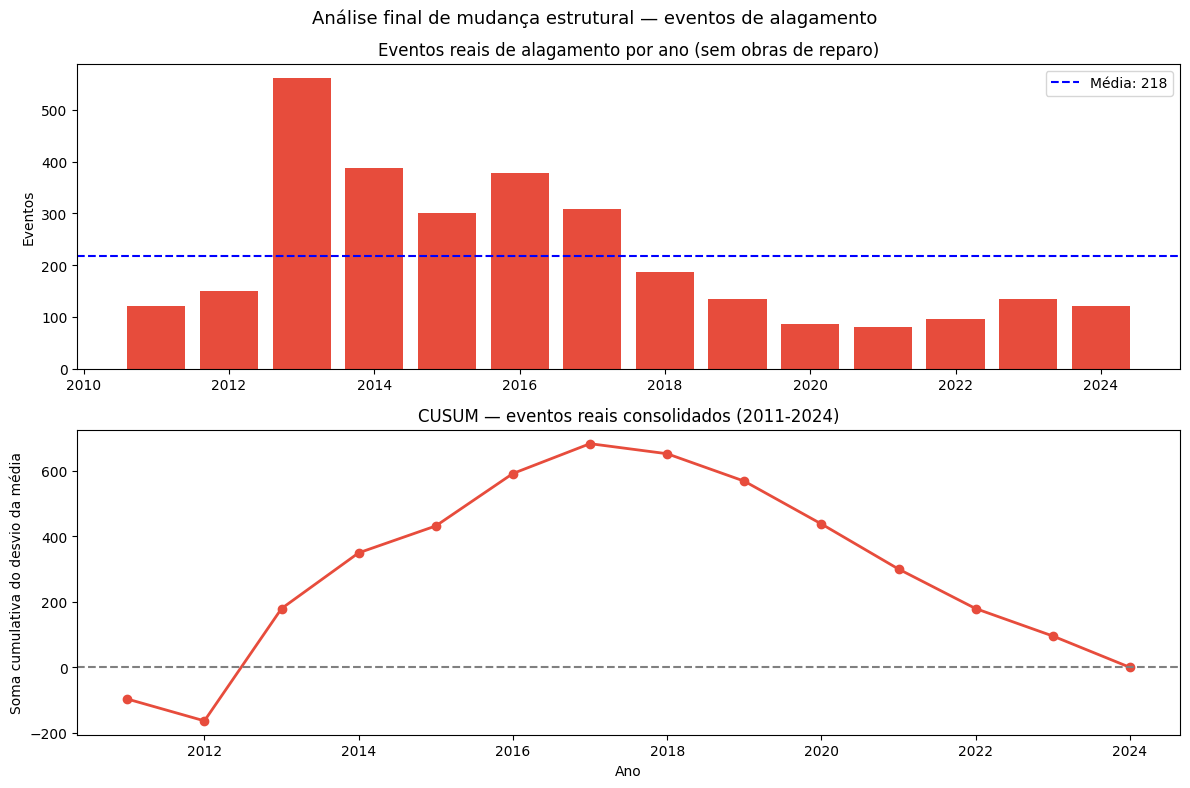

In [16]:
# ── CUSUM final — eventos reais consolidados ──
por_ano_final = (
    df_alagamento[
        (df_alagamento["categoria_chamado"] == "evento_alagamento") &
        (df_alagamento["ano"] <= 2024)  # excluir anos incompletos
    ]
    .groupby("ano")
    .size()
    .reset_index(name="eventos")
)

media = por_ano_final["eventos"].mean()
por_ano_final["cusum"] = (por_ano_final["eventos"] - media).cumsum()

print(por_ano_final.to_string(index=False))

fig, axes = plt.subplots(2, 1, figsize=(12, 8))

axes[0].bar(por_ano_final["ano"], por_ano_final["eventos"], color="#E74C3C")
axes[0].axhline(media, color="blue", linestyle="--", label=f"Média: {media:.0f}")
axes[0].set_title("Eventos reais de alagamento por ano (sem obras de reparo)")
axes[0].set_ylabel("Eventos")
axes[0].legend()

axes[1].plot(por_ano_final["ano"], por_ano_final["cusum"],
             marker="o", color="#E74C3C", linewidth=2)
axes[1].axhline(0, color="gray", linestyle="--")
axes[1].set_title("CUSUM — eventos reais consolidados (2011-2024)")
axes[1].set_ylabel("Soma cumulativa do desvio da média")
axes[1].set_xlabel("Ano")

plt.suptitle("Análise final de mudança estrutural — eventos de alagamento", fontsize=13)
plt.tight_layout()
plt.savefig("../figuras/cusum_final.png", dpi=150)
plt.show()

### Hipotese 3: Ocorreu algum evento climático que justifique o aumento de casos durante 2013-2017

HIPÓTESE 4: Evento climático extremo real
mes_chuvoso  seco  chuvoso  total  pct_chuvoso
ano                                           
2011          106       15    121         12.4
2012          105       46    151         30.5
2013          272      289    561         51.5
2014          223      165    388         42.5
2015          142      158    300         52.7
2016          188      190    378         50.3
2017          183      126    309         40.8
2018          110       77    187         41.2
2019           70       64    134         47.8
2020           30       57     87         65.5
2021           47       33     80         41.2
2022           43       54     97         55.7
2023           68       66    134         49.3
2024           69       53    122         43.4

Média % em meses chuvosos: 44.6%
Desvio padrão: 12.5%


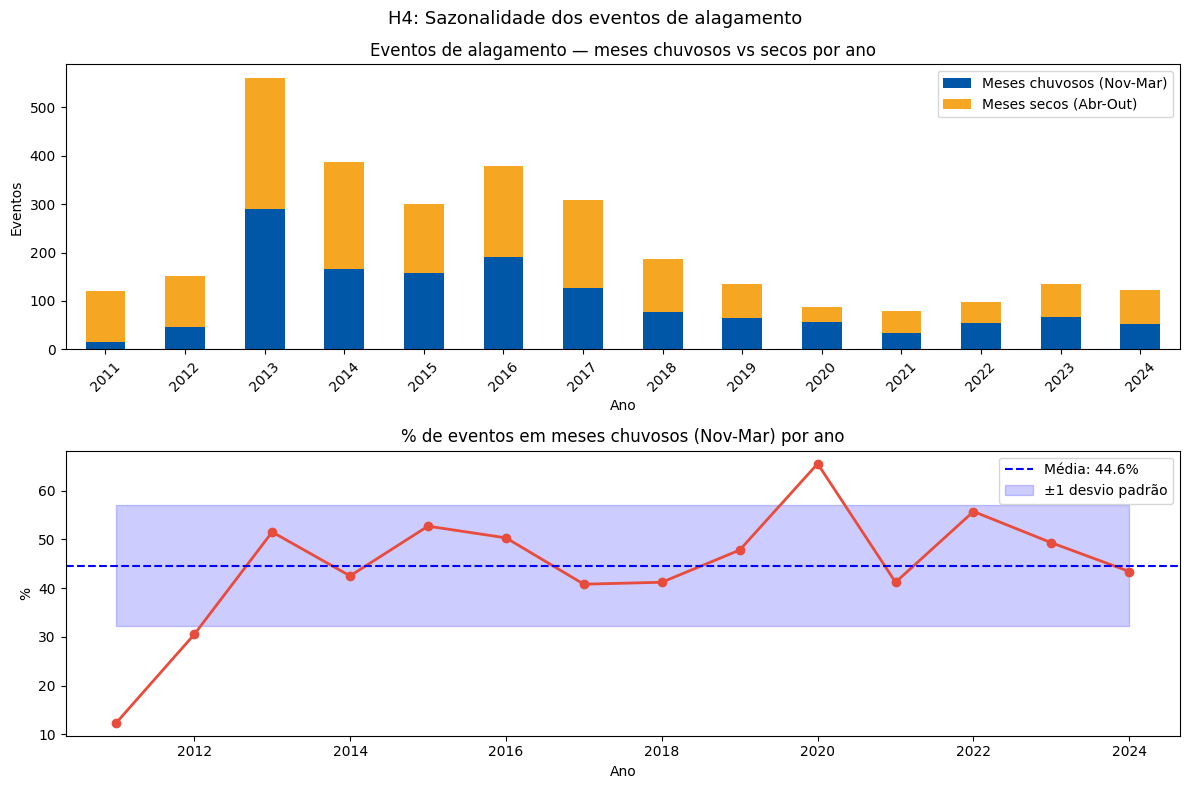

In [ ]:
# ── H4: Sazonalidade dos eventos por ano ──
print("=" * 60)
print("HIPÓTESE 3: Evento climático extremo real")
print("=" * 60)

eventos = df_alagamento[
    (df_alagamento["categoria_chamado"] == "evento_alagamento") &
    (df_alagamento["ano"] >= 2011) &
    (df_alagamento["ano"] <= 2024)
].copy()

# Meses chuvosos no Rio: novembro a março
eventos["mes_chuvoso"] = eventos["mes"].isin([11, 12, 1, 2, 3])

sazonalidade = (
    eventos.groupby(["ano", "mes_chuvoso"])
    .size()
    .reset_index(name="total")
    .pivot(index="ano", columns="mes_chuvoso", values="total")
    .rename(columns={True: "chuvoso", False: "seco"})
    .fillna(0)
    .astype(int)
)

sazonalidade["total"] = sazonalidade["chuvoso"] + sazonalidade["seco"]
sazonalidade["pct_chuvoso"] = (
    sazonalidade["chuvoso"] / sazonalidade["total"] * 100
).round(1)

print(sazonalidade.to_string())

# Estatísticas
print(f"\nMédia % em meses chuvosos: {sazonalidade['pct_chuvoso'].mean():.1f}%")
print(f"Desvio padrão: {sazonalidade['pct_chuvoso'].std():.1f}%")

# Visualização
fig, axes = plt.subplots(2, 1, figsize=(12, 8))

# Volume por mês chuvoso vs seco
sazonalidade[["chuvoso", "seco"]].plot(
    ax=axes[0], kind="bar", stacked=True,
    color=["#0057A8", "#F5A623"]
)
axes[0].set_title("Eventos de alagamento — meses chuvosos vs secos por ano")
axes[0].set_xlabel("Ano")
axes[0].set_ylabel("Eventos")
axes[0].tick_params(axis="x", rotation=45)
axes[0].legend(["Meses chuvosos (Nov-Mar)", "Meses secos (Abr-Out)"])

# % em meses chuvosos
axes[1].plot(
    sazonalidade.index, sazonalidade["pct_chuvoso"],
    marker="o", color="#E74C3C", linewidth=2
)
axes[1].axhline(
    sazonalidade["pct_chuvoso"].mean(),
    color="blue", linestyle="--",
    label=f"Média: {sazonalidade['pct_chuvoso'].mean():.1f}%"
)
axes[1].fill_between(
    sazonalidade.index,
    sazonalidade["pct_chuvoso"].mean() - sazonalidade["pct_chuvoso"].std(),
    sazonalidade["pct_chuvoso"].mean() + sazonalidade["pct_chuvoso"].std(),
    alpha=0.2, color="blue", label="±1 desvio padrão"
)
axes[1].set_title("% de eventos em meses chuvosos (Nov-Mar) por ano")
axes[1].set_xlabel("Ano")
axes[1].set_ylabel("%")
axes[1].legend()

plt.suptitle("H4: Sazonalidade dos eventos de alagamento", fontsize=13)
plt.tight_layout()
plt.savefig("../figuras/h4_sazonalidade.png", dpi=150)
plt.show()

In [18]:
# Recorte temporal justificado pelas hipóteses
df_eventos_final = df_alagamento[
    (df_alagamento["categoria_chamado"] == "evento_alagamento") &
    (df_alagamento["ano"] >= 2012) &  # excluir 2011 — ano incompleto
    (df_alagamento["ano"] <= 2024)    # excluir 2025/2026 — anos incompletos
].copy()

print(f"Eventos para o índice: {len(df_eventos_final):,}")
print(f"Período: {df_eventos_final['ano'].min()} a {df_eventos_final['ano'].max()}")
print(f"Média anual: {len(df_eventos_final) / df_eventos_final['ano'].nunique():.0f}")

Eventos para o índice: 2,928
Período: 2012 a 2024
Média anual: 225


In [19]:
# Célula 6: cruzamento com bairros corrigido 

# Buscar bairros com área para normalização posterior
query_bairros = """
SELECT
    id_bairro,
    nome AS bairro,
FROM `datario.dados_mestres.bairro`
"""


df_bairros = client.query(query_bairros).to_dataframe()

if "bairro" in df_alagamento.columns:
    df_alagamento = df_alagamento.drop(columns="bairro")

# Alinhar tipos para merge
df_alagamento["id_bairro"] = df_alagamento["id_bairro"].astype(str)
df_bairros["id_bairro"]    = df_bairros["id_bairro"].astype(str)

df_alagamento = df_alagamento.merge(df_bairros, on="id_bairro", how="left")

# Padronizar nome do bairro
df_alagamento["bairro"] = (
    df_alagamento["bairro"]
    .str.strip()
    .str.upper()
    .str.normalize("NFC")
)

df_eventos_bairro = df_alagamento[
    df_alagamento["categoria_chamado"] == "evento_alagamento"
].copy()

sem_bairro = df_alagamento["bairro"].isna().sum()

print(f"\nChamados sem bairro: {sem_bairro.sum():,} ({sem_bairro.mean()*100:.1f}%)")
print(f"\nTop 20 bairros com mais chamados de alagamento:")
print(df_eventos_bairro["bairro"].value_counts().head(20))


Chamados sem bairro: 35,247 (3524700.0%)

Top 20 bairros com mais chamados de alagamento:
bairro
CAMPO GRANDE         43
SANTA CRUZ           41
GUARATIBA            36
REALENGO             35
BANGU                18
PADRE MIGUEL         15
TIJUCA               12
MARACANÃ             12
JACAREPAGUÁ          10
PIEDADE               9
BENTO RIBEIRO         9
IRAJÁ                 9
ANDARAÍ               8
ILHA DE GUARATIBA     8
PACIÊNCIA             8
BARRA DA TIJUCA       7
PAVUNA                7
TAQUARA               7
PRAÇA DA BANDEIRA     7
SEPETIBA              6
Name: count, dtype: int64


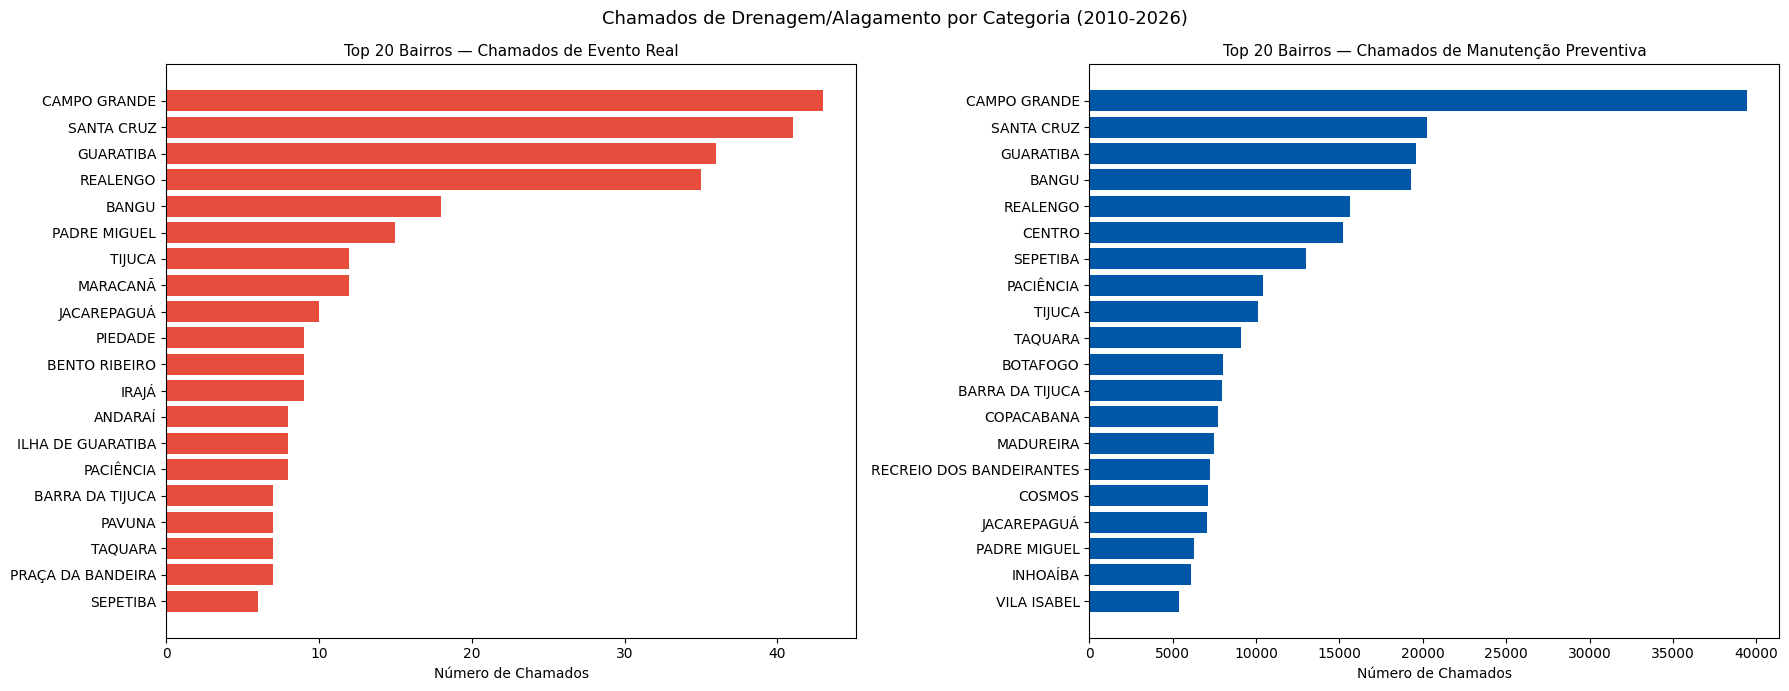

Gráfico 1 salvo


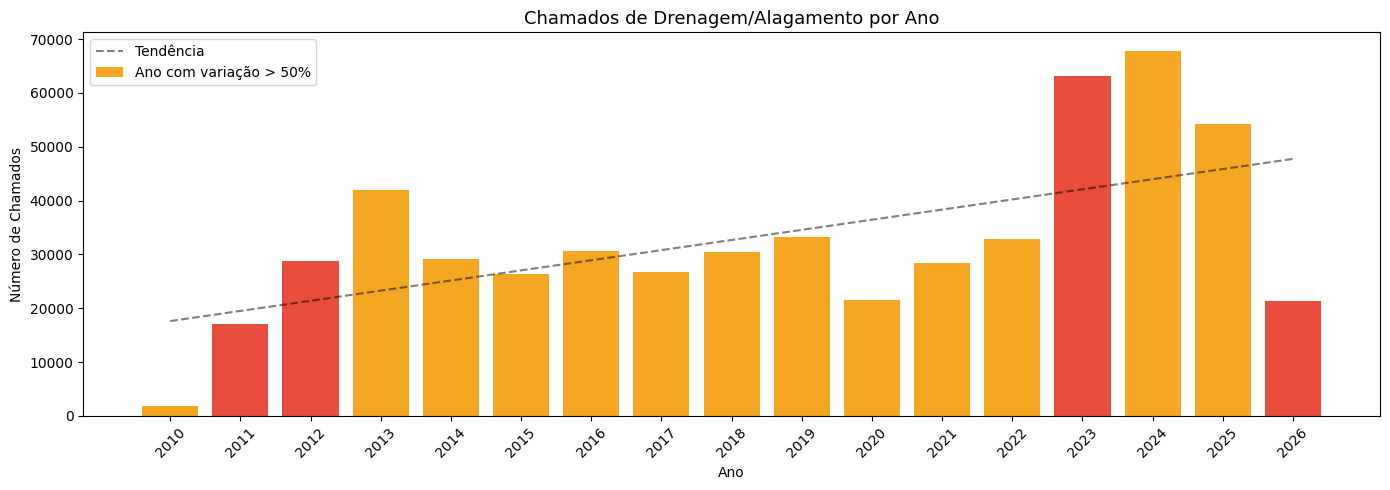

Gráfico 2 salvo


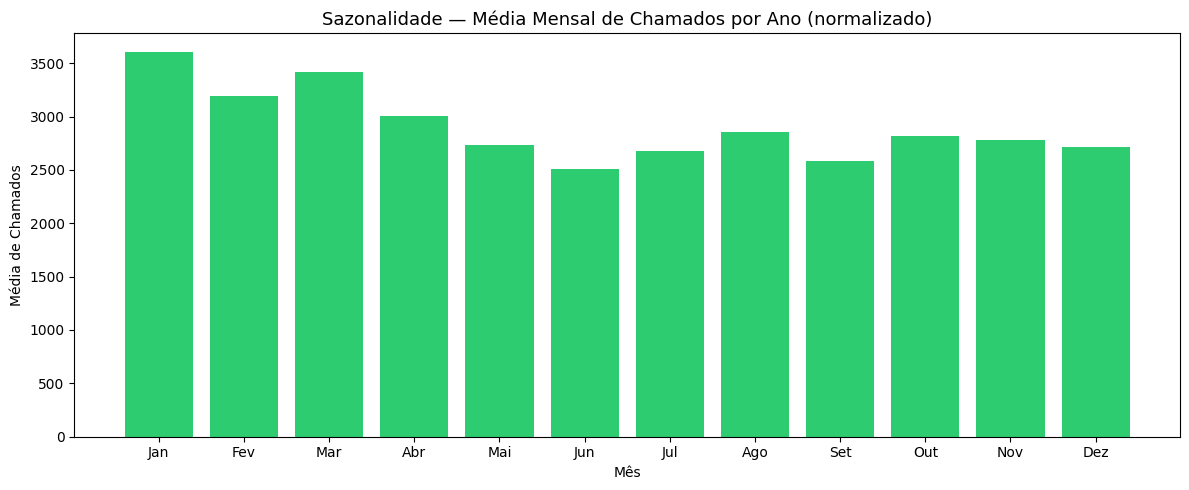

Gráfico 3 salvo


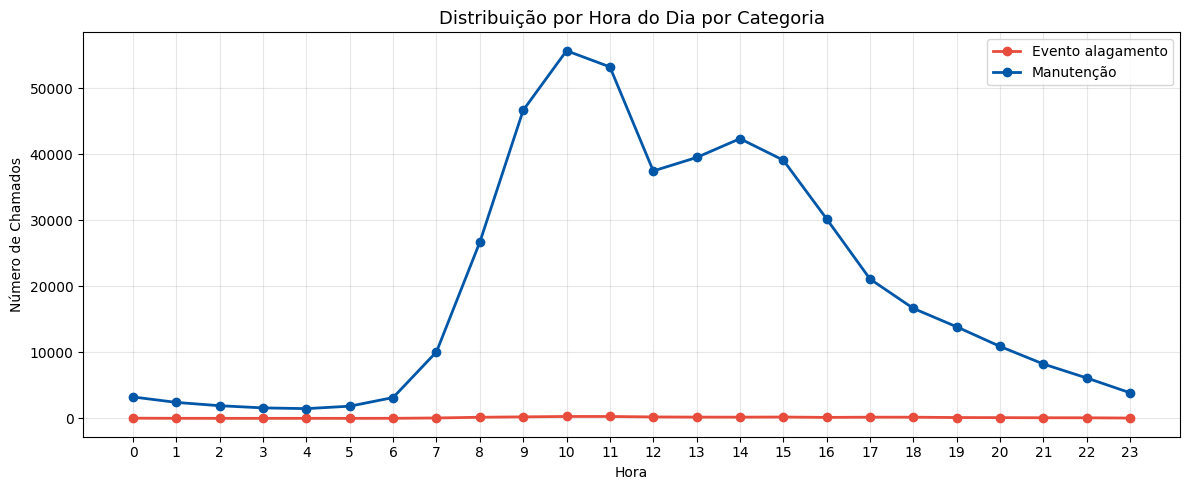

Gráfico 4 salvo


In [20]:
# ── Célula: gráficos corrigidos ──
import matplotlib.pyplot as plt
import numpy as np
import os

os.makedirs("../figuras", exist_ok=True)
meses = ["Jan","Fev","Mar","Abr","Mai","Jun","Jul","Ago","Set","Out","Nov","Dez"]

# GRÁFICO 1: Top 20 bairros por categoria
# CORREÇÃO 1: categoria correta é "evento_alagamento" não "evento"
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

for ax, categoria, titulo, cor in zip(
    axes,
    ["evento_alagamento", "manutencao"],   # ← corrigido
    ["Chamados de Evento Real", "Chamados de Manutenção Preventiva"],
    ["#E74C3C", "#0057A8"]
):
    top20 = (
        df_alagamento[df_alagamento["categoria_chamado"] == categoria]
        ["bairro"].value_counts().head(20)
    )
    ax.barh(top20.index[::-1], top20.values[::-1], color=cor)
    ax.set_title(f"Top 20 Bairros — {titulo}", fontsize=11)
    ax.set_xlabel("Número de Chamados")

plt.suptitle("Chamados de Drenagem/Alagamento por Categoria (2010-2026)", fontsize=13)
plt.tight_layout()
plt.savefig("../figuras/top20_bairros_por_categoria.png", dpi=150)
plt.show()
print("Gráfico 1 salvo")

# GRÁFICO 2: Chamados por ano
# CORREÇÃO 2: anos_suspeitos pode não estar definido — calcular aqui
por_ano = df_alagamento.groupby("ano").size()
variacao = por_ano.pct_change() * 100
anos_suspeitos = variacao[variacao.abs() > 50].index.tolist()
cores = ["#E74C3C" if a in anos_suspeitos else "#F5A623" for a in por_ano.index]

plt.figure(figsize=(14, 5))
plt.bar(por_ano.index, por_ano.values, color=cores)
plt.title("Chamados de Drenagem/Alagamento por Ano", fontsize=13)
plt.xlabel("Ano")
plt.ylabel("Número de Chamados")
plt.xticks(por_ano.index, rotation=45)

z = np.polyfit(por_ano.index, por_ano.values, 1)
p = np.poly1d(z)
plt.plot(por_ano.index, p(por_ano.index), "k--", alpha=0.5, label="Tendência")
if anos_suspeitos:
    plt.legend(["Tendência", "Ano com variação > 50%"])
plt.tight_layout()
plt.savefig("../figuras/chamados_por_ano.png", dpi=150)
plt.show()
print("Gráfico 2 salvo")

# GRÁFICO 3: Sazonalidade normalizada
por_mes_normalizado = (
    df_alagamento.groupby(["ano", "mes"])
    .size()
    .reset_index(name="chamados")
    .groupby("mes")["chamados"]
    .mean()
    .round(0)
)

plt.figure(figsize=(12, 5))
plt.bar(meses, por_mes_normalizado.values, color="#2ECC71")
plt.title("Sazonalidade — Média Mensal de Chamados por Ano (normalizado)", fontsize=13)
plt.xlabel("Mês")
plt.ylabel("Média de Chamados")
plt.tight_layout()
plt.savefig("../figuras/sazonalidade_normalizada.png", dpi=150)
plt.show()
print("Gráfico 3 salvo")

# GRÁFICO 4: Distribuição por hora
# CORREÇÃO 3: categoria correta é "evento_alagamento" não "evento"
por_hora_evento = (
    df_alagamento[df_alagamento["categoria_chamado"] == "evento_alagamento"]  # ← corrigido
    .groupby("hora").size()
)
por_hora_manut = (
    df_alagamento[df_alagamento["categoria_chamado"] == "manutencao"]
    .groupby("hora").size()
)

plt.figure(figsize=(12, 5))
plt.plot(por_hora_evento.index, por_hora_evento.values,
         color="#E74C3C", linewidth=2, marker="o", label="Evento alagamento")
plt.plot(por_hora_manut.index, por_hora_manut.values,
         color="#0057A8", linewidth=2, marker="o", label="Manutenção")
plt.title("Distribuição por Hora do Dia por Categoria", fontsize=13)
plt.xlabel("Hora")
plt.ylabel("Número de Chamados")
plt.xticks(range(0, 24))
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("../figuras/chamados_por_hora.png", dpi=150)
plt.show()
print("Gráfico 4 salvo")

In [24]:
print(f"Bairros preenchidos: {df_alagamento['bairro'].notna().sum():,} ({df_alagamento['bairro'].notna().mean()*100:.1f}%)")
print(f"Bairros nulos:       {df_alagamento['bairro'].isna().sum():,}")

# Verificar nos eventos reais especificamente
eventos = df_alagamento[
    (df_alagamento["categoria_chamado"] == "evento_alagamento") &
    (df_alagamento["ano"] >= 2012) &
    (df_alagamento["ano"] <= 2024)
]
print(f"\nEventos reais: {len(eventos):,}")
print(f"Com bairro:    {eventos['bairro'].notna().sum():,}")
print(f"Sem bairro:    {eventos['bairro'].isna().sum():,}")
print(f"\nTop 10 bairros nos eventos:")
print(eventos["bairro"].value_counts().head(10))


Bairros preenchidos: 520,172 (93.7%)
Bairros nulos:       35,247

Eventos reais: 2,928
Com bairro:    335
Sem bairro:    2,593

Top 10 bairros nos eventos:
bairro
CAMPO GRANDE       34
GUARATIBA          27
REALENGO           25
SANTA CRUZ         17
PADRE MIGUEL       13
BANGU              12
JACAREPAGUÁ        10
PIEDADE             8
BARRA DA TIJUCA     7
TIJUCA              7
Name: count, dtype: int64


In [25]:
# ── Célula: salvamento corrigido ──
import pyarrow
import os

# Remover colunas duplicadas de bairro antes de salvar
if "bairro_x" in df_alagamento.columns:
    # bairro_x é a versão maiúscula e mais completa — manter como bairro
    df_alagamento["bairro"] = df_alagamento["bairro_x"]
    df_alagamento = df_alagamento.drop(columns=["bairro_x", "bairro_y"], errors="ignore")

# Verificar colunas finais
print(f"Colunas no DataFrame: {df_alagamento.columns.tolist()}")
print(f"Bairros preenchidos: {df_alagamento['bairro'].notna().sum():,} ({df_alagamento['bairro'].notna().mean()*100:.1f}%)")

# Salvar
os.makedirs("../data/processed", exist_ok=True)
caminho = "../data/processed/chamados_alagamento.parquet"
df_alagamento.to_parquet(caminho, index=False)

df_teste = pd.read_parquet(caminho)
print(f"Arquivo salvo com sucesso!")
print(f"  Linhas:         {len(df_teste):,}")
print(f"  Colunas:        {df_teste.columns.tolist()}")
print(f"  Período:        {df_teste['ano'].min()} a {df_teste['ano'].max()}")
print(f"  Bairros únicos: {df_teste['bairro'].nunique()}")
print(f"\nDistribuição por categoria:")
print(df_teste["categoria_chamado"].value_counts())

Colunas no DataFrame: ['id_chamado', 'id_origem_ocorrencia', 'data_inicio', 'data_fim', 'tipo', 'subtipo', 'status', 'situacao', 'id_bairro', 'latitude', 'longitude', 'categoria_chamado', 'data', 'ano', 'mes', 'hora', 'dia_semana', 'bairro']
Bairros preenchidos: 520,172 (93.7%)
Arquivo salvo com sucesso!
  Linhas:         555,419
  Colunas:        ['id_chamado', 'id_origem_ocorrencia', 'data_inicio', 'data_fim', 'tipo', 'subtipo', 'status', 'situacao', 'id_bairro', 'latitude', 'longitude', 'categoria_chamado', 'data', 'ano', 'mes', 'hora', 'dia_semana', 'bairro']
  Período:        2010 a 2026
  Bairros únicos: 166

Distribuição por categoria:
categoria_chamado
manutencao           477898
informativo           55177
obra_reparo           19186
evento_alagamento      3158
Name: count, dtype: int64
